In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/AB_NYC_2019.csv")

In [ ]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data.shape

(48895, 16)

In [ ]:
data.size

782320

In [ ]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
data.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
data.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [ ]:
obj = data.select_dtypes(include="object")

In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

In [ ]:
for x in obj:
  data[x] = LE.fit_transform(data[x])

In [ ]:
data.dtypes

,0
id,int64
name,int64
host_id,int64
host_name,int64
neighbourhood_group,int64
neighbourhood,int64
latitude,float64
longitude,float64
room_type,int64
price,int64


In [ ]:
data.fillna(data.mean(), inplace=True)

In [ ]:
data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
corr = data.corr()

/tmp/ipykernel_290/3900258321.py:3: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the title


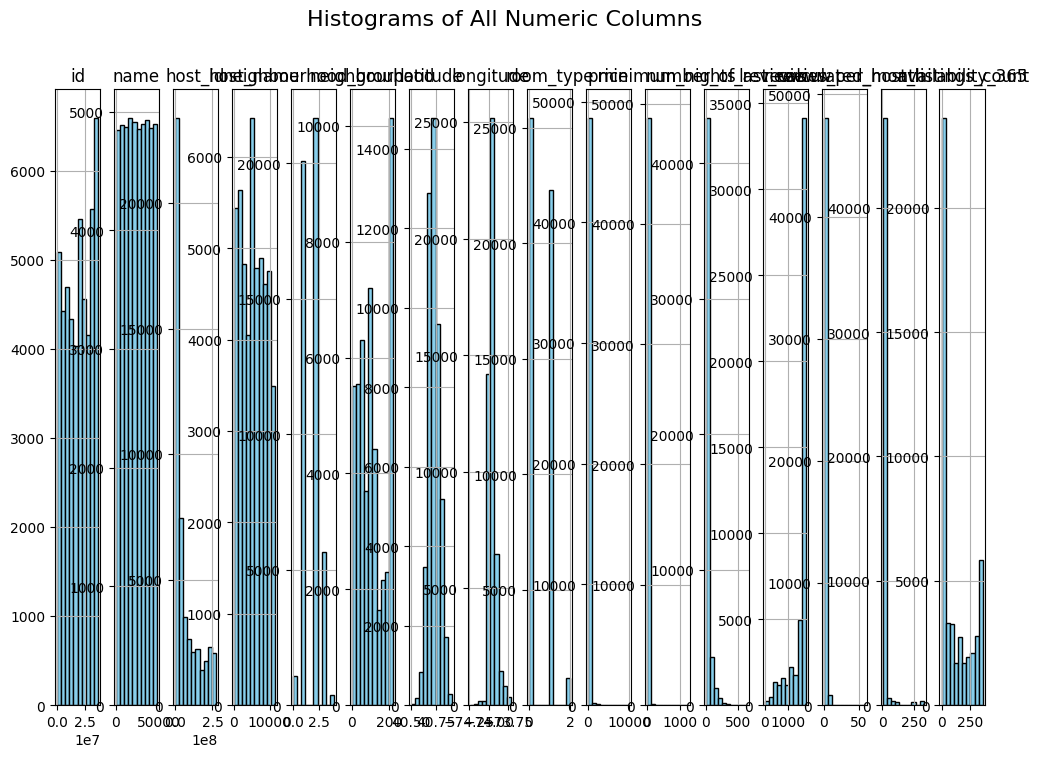

In [ ]:
data.hist(bins=10, figsize=(12,8), layout=(1, len(data.columns)), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of All Numeric Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the title
plt.show()

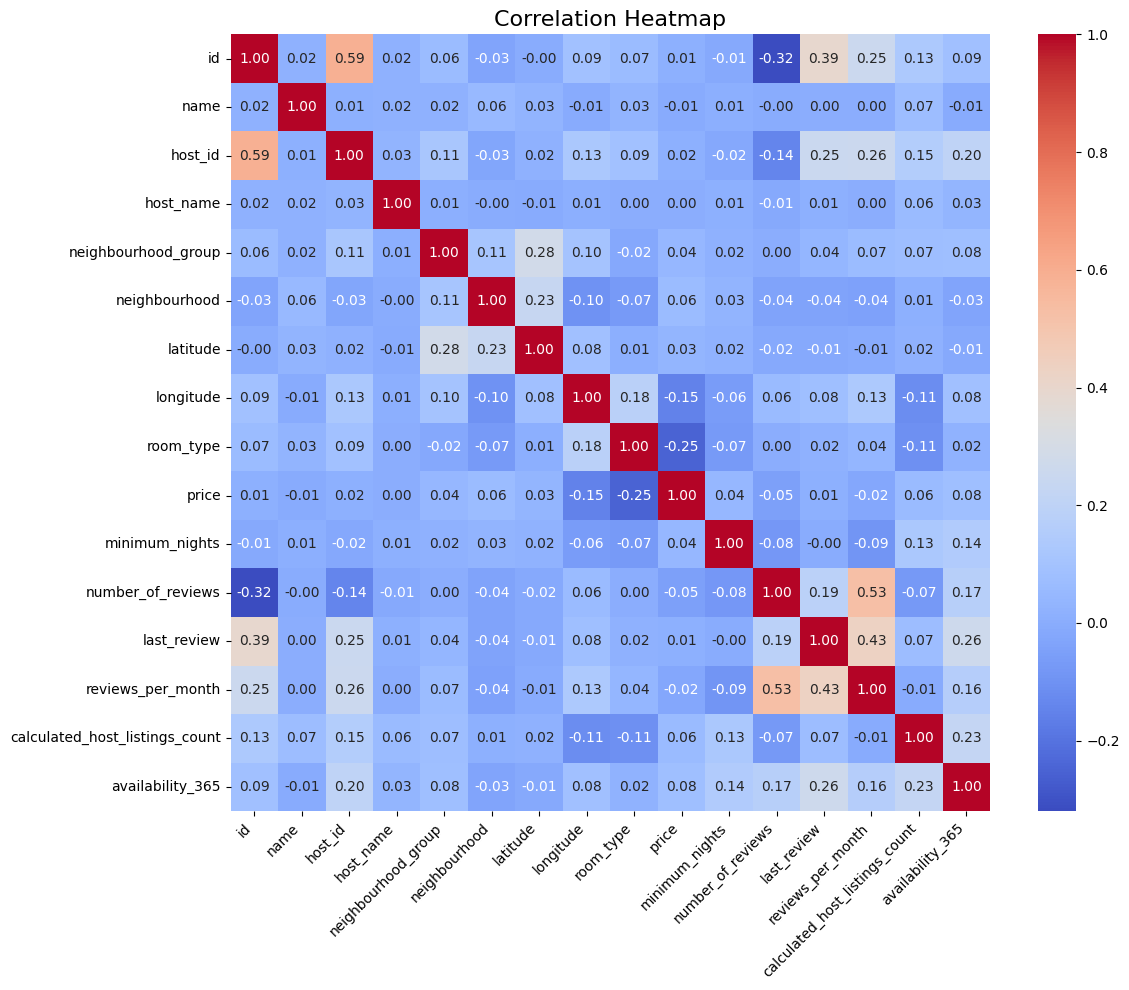

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size":10}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

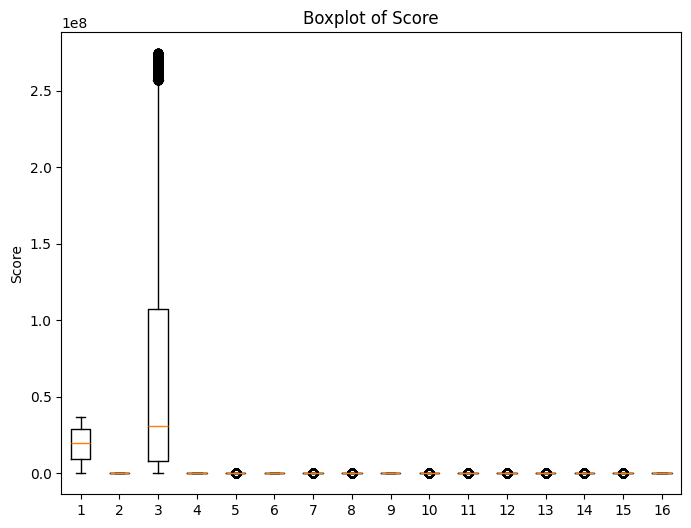

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(data)
plt.title("Boxplot of Score")
plt.ylabel("Score")
plt.show()

/tmp/ipykernel_290/473925179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="room_type", y="price", data=data, jitter=True, size=8, palette="Set2")


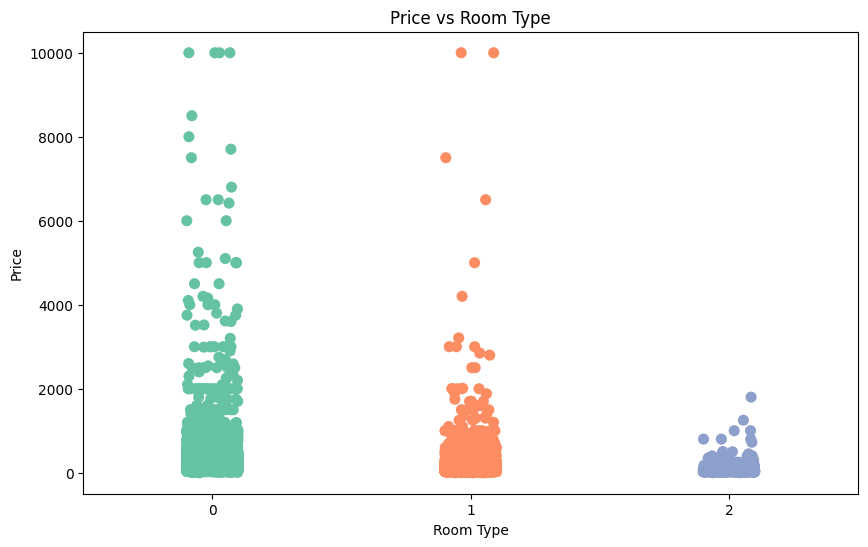

In [ ]:
plt.figure(figsize=(10,6))
sns.stripplot(x="room_type", y="price", data=data, jitter=True, size=8, palette="Set2")
plt.title("Price vs Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

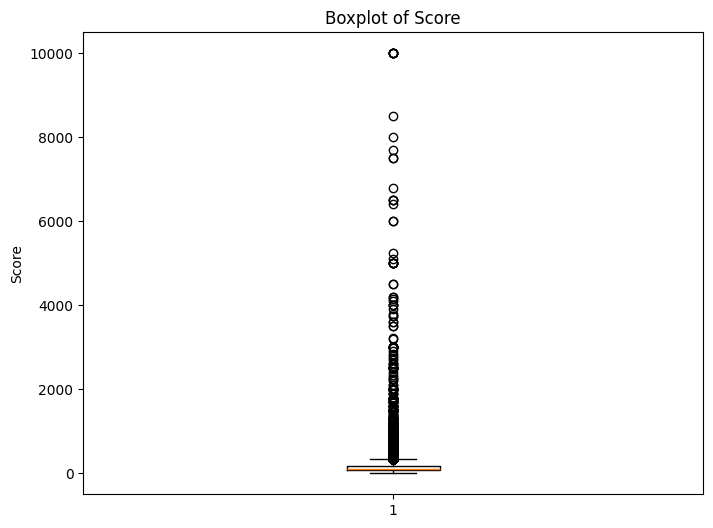

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(data["price"])
plt.title("Boxplot of Score")
plt.ylabel("Score")
plt.show()

In [ ]:
data['price'].min()

0

In [ ]:
data["price"].max()

10000

In [ ]:
from scipy import stats
data['z_score'] = np.abs(stats.zscore(data['price']))

# Detect outliers (z > 3)
outliers = data[data['z_score'] > 3]

print("Outliers:")
print(outliers)

Outliers:
             id   name    host_id  host_name  neighbourhood_group  \
496      174966  26838     836168       4068                    2   
762      273190   2703     605463      10887                    2   
946      363673   5590     256239      10453                    2   
1105     468613    136    2325861       2180                    2   
1414     634353  26782     836168       4068                    2   
...         ...    ...        ...        ...                  ...   
48301  36186719  32840  268920555      10237                    2   
48304  36189195  30437  270214015       8859                    2   
48305  36189257   2132  272166348       6865                    2   
48523  36308562  43626  217732163       9179                    1   
48535  36311055  40901  245712163      10576                    1   

       neighbourhood  latitude  longitude  room_type  price  minimum_nights  \
496              202  40.77350  -73.98697          0   2000              30   
762

In [ ]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_clean = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]


print("Cleaned data:")
print(data_clean)

Cleaned data:
             id   name   host_id  host_name  neighbourhood_group  \
0          2539  12328      2787       4989                    1   
1          2595  37455      2845       4785                    2   
2          3647  43543      4632       2909                    2   
3          3831  14783      4869       6203                    1   
4          5022  18693      7192       5923                    2   
...         ...    ...       ...        ...                  ...   
48890  36484665  11647   8232441       9051                    1   
48891  36485057   3520   6570630       6776                    1   
48892  36485431  42464  23492952       4263                    2   
48893  36485609   2572  30985759      10190                    2   
48894  36487245  44538  68119814       1968                    2   

       neighbourhood  latitude  longitude  room_type  price  minimum_nights  \
0                108  40.64749  -73.97237          1    149               1   
1          

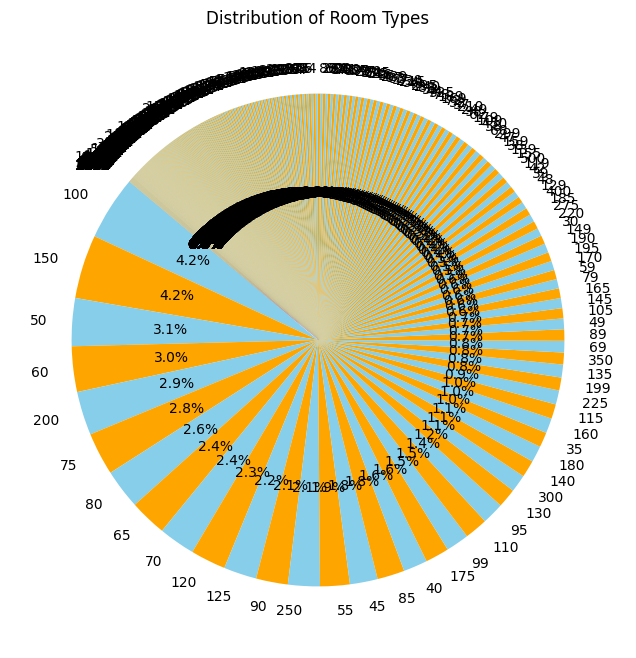

In [ ]:
room_counts = data['price'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange'])
plt.title("Distribution of Room Types")
plt.show()

In [ ]:
data["price"]

array([  149,   225,   150,    89,    80,   200,    60,    79,   135,
          85,   120,   140,   215,    99,   190,   299,   130,   110,
          44,   180,    50,    52,    55,    70,    35,    40,    68,
         115,   151,   228,   144,    69,    49,   375,   250,   275,
         230,    51,    65,   105,    95,   145,   285,    94,   800,
         131,    98,   100,   125,   175,   500,   101,   220,    59,
         350,   199,   325,   235,   170,   400,    75,    90,   185,
          77,    76,   160,   195,   156,   219,   475,   165,   196,
          83,   123,   265,   249,   121,    45,    71,    64,   159,
         189,   239,   305,   155,    92,    36,    37,   205,    39,
         390,   129,   212,   124,   122,   109,   575,   229,   169,
         113,   179,   349,   139,   650,    67,   599,   211,   290,
          87,   395,   260,    97,   132,   141,   495,   259,    96,
         295,   451,   300,    42,   255,    72,    88,   450,   198,
          46,    33,

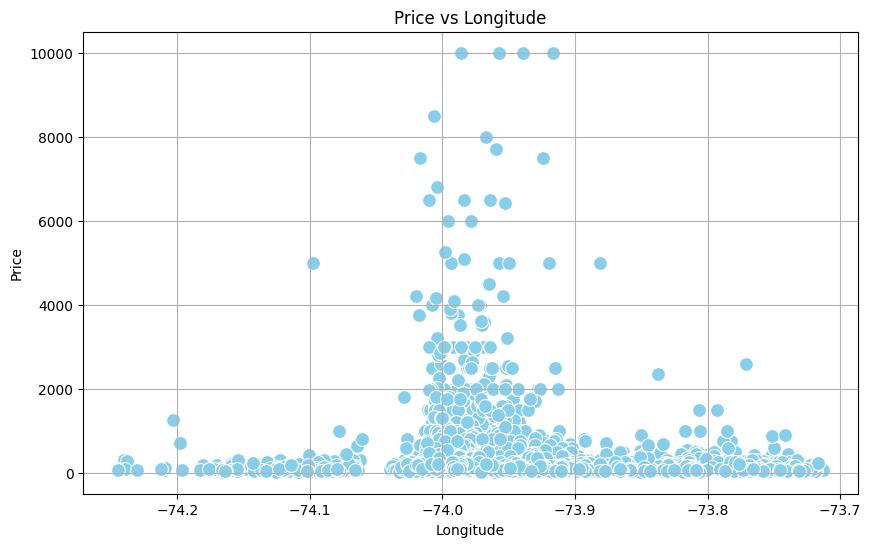

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="longitude", y="price", data=data, s=100, color="skyblue")
plt.title("Price vs Longitude")
plt.xlabel("Longitude")
plt.ylabel("Price")
plt.grid(True)
plt.show()